<a href="https://colab.research.google.com/github/flango2023/Pulso_F2/blob/main/fase2_irale%CC%81m2_mlp_ecg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pulso_Fase_2 (Ir Além): Classificação de ECG com Rede Neural MLP

**Projeto:** Pulso: Inteligência Cardiológica com Consciência de Dados  
**Autor:** Richard Schmitz | RM 567951  


---

## Objetivo

Este notebook implementa o Ir Além 2 da Fase 2 do projeto Pulso.  
Utilizando o dataset MIT-BIH Arrhythmia (via Kaggle — shayanfazeli/heartbeat),  
o sistema treina uma Rede Neural MLP (Perceptron Multicamadas) para classificar  
sinais de ECG como **normal** ou **anormal**.

### Sobre o dataset

O dataset contém sinais de ECG segmentados em batimentos individuais,  
cada um representado por 187 pontos de amplitude ao longo do tempo.  
As classes originais são:

| Classe | Descrição | Mapeamento |
|--------|-----------|------------|
| 0 | Normal | Normal |
| 1 | Supraventricular | Anormal |
| 2 | Ventricular | Anormal |
| 3 | Fusão | Anormal |
| 4 | Não classificado | Anormal |

Para este projeto, as classes 1–4 são agrupadas em **anormal**,  
criando um problema de classificação binária alinhado com o objetivo clínico:  
identificar se um batimento cardíaco é normal ou requer atenção médica.

### Conexão com a Fase 1

Este módulo complementa o dataset numérico UCI Cleveland da Fase 1.  
Enquanto o Cleveland usa variáveis clínicas para prever doença coronariana,  
este módulo usa o sinal elétrico do coração para detectar arritmias —  
duas perspectivas complementares do mesmo problema cardiovascular.

## 1. Configuração do ambiente e importações

> **Google Colab:** baixe o dataset em https://www.kaggle.com/datasets/shayanfazeli/heartbeat  
> e faça upload de `mitbih_train.csv` e `mitbih_test.csv` antes de executar.  
> Alternativamente, use a Kaggle API conforme instruções abaixo.

In [1]:
# === Kaggle API (opcional) ===
# 1. Acesse https://www.kaggle.com/settings e gere um token API (kaggle.json)
# 2. Faça upload do kaggle.json no Colab
# 3. Descomente e execute as linhas abaixo:
# !pip install kaggle -q
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d shayanfazeli/heartbeat --unzip

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Importação compatível com TensorFlow 2.x e versões mais recentes
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from tensorflow.keras.models import Sequential

# Detecta ambiente de execução
try:
    import google.colab
    COLAB = True
except ImportError:
    COLAB = False

# Define caminhos de acordo com o ambiente
if COLAB:
    CAMINHO_TREINO = '/content/mitbih_train.csv'
    CAMINHO_TESTE  = '/content/mitbih_test.csv'
    CAMINHO_SAIDA  = '/content/'
else:
    CAMINHO_TREINO = '../data/mitbih_train.csv'
    CAMINHO_TESTE  = '../data/mitbih_test.csv'
    CAMINHO_SAIDA  = '../data/'

print(f'TensorFlow versão : {tf.__version__}')
print(f'Ambiente          : {"Google Colab" if COLAB else "Local"}')
print('Importações concluídas.')

TensorFlow versão : 2.21.0
Ambiente          : Google Colab
Importações concluídas.


## 2. Carregamento do dataset

In [2]:
# Carrega os arquivos CSV — sem header, última coluna é o rótulo
df_train = pd.read_csv(CAMINHO_TREINO, header=None)
df_test  = pd.read_csv(CAMINHO_TESTE,  header=None)

print(f'Treino : {df_train.shape[0]:,} batimentos, {df_train.shape[1]-1} features + 1 rótulo')
print(f'Teste  : {df_test.shape[0]:,} batimentos, {df_test.shape[1]-1} features + 1 rótulo')

# Exibe distribuição original das 5 classes
classes_orig = {0: 'Normal', 1: 'Supraventricular', 2: 'Ventricular', 3: 'Fusão', 4: 'Não classificado'}
print('\nDistribuição original das classes (treino):')
contagem = df_train.iloc[:, -1].value_counts().sort_index()
for cls, count in contagem.items():
    print(f'  Classe {int(cls)} ({classes_orig[int(cls)]}): {count:,} batimentos')

Treino : 87,554 batimentos, 187 features + 1 rótulo
Teste  : 21,892 batimentos, 187 features + 1 rótulo

Distribuição original das classes (treino):
  Classe 0 (Normal): 72,471 batimentos
  Classe 1 (Supraventricular): 2,223 batimentos
  Classe 2 (Ventricular): 5,788 batimentos
  Classe 3 (Fusão): 641 batimentos
  Classe 4 (Não classificado): 6,431 batimentos


## 3. Pré-processamento

### 3.1 Conversão para classificação binária

Classes 1–4 são agrupadas em **anormal (1)**.  
Classe 0 permanece como **normal (0)**.

### 3.2 Balanceamento

O dataset original é fortemente desbalanceado (~72% normal).  
Para evitar que o modelo aprenda a prever sempre "normal",  
aplicamos undersampling na classe majoritária.

In [3]:
def preparar_dados(df, n_amostras_por_classe=5000):
    """
    Separa features e rótulos, converte para binário e balanceia por undersampling.
    Retorna X (features) e y (rótulos binários).
    """
    X = df.iloc[:, :-1].values          # todas as colunas exceto a última
    y_orig = df.iloc[:, -1].values.astype(int)  # última coluna = rótulo

    # Converte para binário: 0 = normal, 1 = anormal (qualquer classe > 0)
    y = (y_orig > 0).astype(int)

    # Índices de cada classe
    idx_normal  = np.where(y == 0)[0]
    idx_anormal = np.where(y == 1)[0]

    # Usa o mínimo entre o solicitado e o disponível em cada classe
    n = min(n_amostras_por_classe, len(idx_normal), len(idx_anormal))

    # Amostragem aleatória reprodutível
    np.random.seed(42)
    idx_normal_bal  = np.random.choice(idx_normal,  n, replace=False)
    idx_anormal_bal = np.random.choice(idx_anormal, n, replace=False)

    # Concatena e embaralha os índices selecionados
    idx_bal = np.concatenate([idx_normal_bal, idx_anormal_bal])
    np.random.shuffle(idx_bal)

    return X[idx_bal], y[idx_bal]


X_train, y_train = preparar_dados(df_train, n_amostras_por_classe=5000)
X_test,  y_test  = preparar_dados(df_test,  n_amostras_por_classe=1000)

print(f'Treino balanceado : {X_train.shape[0]:,} batimentos')
print(f'  Normal  : {(y_train == 0).sum():,}')
print(f'  Anormal : {(y_train == 1).sum():,}')
print(f'\nTeste balanceado  : {X_test.shape[0]:,} batimentos')
print(f'  Normal  : {(y_test == 0).sum():,}')
print(f'  Anormal : {(y_test == 1).sum():,}')

Treino balanceado : 10,000 batimentos
  Normal  : 5,000
  Anormal : 5,000

Teste balanceado  : 2,000 batimentos
  Normal  : 1,000
  Anormal : 1,000


### 3.3 Normalização

Redes neurais convergem mais rápido quando as features têm média zero e desvio padrão unitário.  
O scaler é ajustado apenas no treino e aplicado ao teste — evita data leakage.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # aprende média e desvio no treino
X_test_scaled  = scaler.transform(X_test)        # aplica a mesma escala ao teste

print('Normalização concluída.')
print(f'Shape final de treino : {X_train_scaled.shape}')
print(f'Shape final de teste  : {X_test_scaled.shape}')

Normalização concluída.
Shape final de treino : (10000, 187)
Shape final de teste  : (2000, 187)


## 4. Visualização de batimentos cardíacos

Cada linha do dataset representa um batimento cardíaco segmentado em 187 pontos de amplitude.

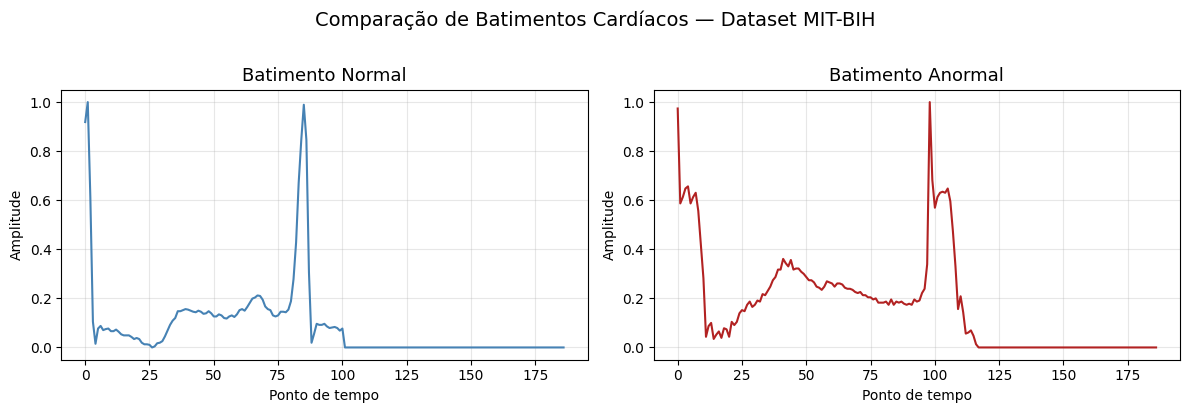

Gráfico salvo em: /content/batimentos_exemplo.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Seleciona o primeiro exemplo de cada classe para visualização
idx_normal  = np.where(y_train == 0)[0][0]
idx_anormal = np.where(y_train == 1)[0][0]

axes[0].plot(X_train[idx_normal], color='steelblue', linewidth=1.5)
axes[0].set_title('Batimento Normal', fontsize=13)
axes[0].set_xlabel('Ponto de tempo')
axes[0].set_ylabel('Amplitude')
axes[0].grid(alpha=0.3)

axes[1].plot(X_train[idx_anormal], color='firebrick', linewidth=1.5)
axes[1].set_title('Batimento Anormal', fontsize=13)
axes[1].set_xlabel('Ponto de tempo')
axes[1].set_ylabel('Amplitude')
axes[1].grid(alpha=0.3)

plt.suptitle('Comparação de Batimentos Cardíacos — Dataset MIT-BIH', fontsize=14, y=1.02)
plt.tight_layout()

# Salva o gráfico no caminho correto para o ambiente
caminho_fig = os.path.join(CAMINHO_SAIDA, 'batimentos_exemplo.png')
plt.savefig(caminho_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfico salvo em: {caminho_fig}')

## 5. Arquitetura da rede neural MLP

A rede recebe 187 features (pontos do sinal de ECG) e produz uma probabilidade binária.

```
Input (187)  →  Dense(128, ReLU)  →  Dropout(0.3)
             →  Dense(64, ReLU)   →  Dropout(0.3)
             →  Dense(32, ReLU)
             →  Dense(1, Sigmoid)  →  Normal / Anormal
```

- **ReLU**: evita o problema do gradiente desaparecendo em camadas profundas
- **Dropout**: desativa aleatoriamente neurônios durante o treino para reduzir overfitting
- **Sigmoid**: produz uma probabilidade entre 0 e 1 para classificação binária

In [6]:
def construir_modelo(input_dim):
    """Constrói e compila a rede MLP para classificação binária."""
    modelo = Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),   # primeira camada oculta
        layers.Dropout(0.3),                    # regularização
        layers.Dense(64, activation='relu'),    # segunda camada oculta
        layers.Dropout(0.3),                    # regularização
        layers.Dense(32, activation='relu'),    # terceira camada oculta
        layers.Dense(1, activation='sigmoid')   # saída: probabilidade binária
    ])
    modelo.compile(
        optimizer='adam',
        loss='binary_crossentropy',  # função de perda para classificação binária
        metrics=['accuracy']
    )
    return modelo


modelo = construir_modelo(X_train_scaled.shape[1])
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        24,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,433 (134.50 KB)

 Trainable params: 34,433 (134.50 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Treinamento

In [7]:
# EarlyStopping: interrompe o treino se val_loss não melhorar por 5 épocas
# restore_best_weights: restaura os pesos da melhor época ao final
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

historico = modelo.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,   # 20% do treino usado para validação
    callbacks=[early_stop],
    verbose=1
)

print(f'\nTreinamento concluído em {len(historico.history["loss"])} épocas.')

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7709 - loss: 0.4807 - val_accuracy: 0.8475 - val_loss: 0.3579
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8534 - loss: 0.3435 - val_accuracy: 0.8705 - val_loss: 0.3138
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8760 - loss: 0.3044 - val_accuracy: 0.8850 - val_loss: 0.2848
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8909 - loss: 0.2685 - val_accuracy: 0.9000 - val_loss: 0.2613
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8956 - loss: 0.2562 - val_accuracy: 0.9025 - val_loss: 0.2465
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9070 - loss: 0.2369 - val_accuracy: 0.9065 - val_loss: 0.2363
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9086 - loss: 0.2266 - val_accuracy: 0.9065 - val_loss: 0.2213
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9146 - loss: 0.2183 - val_accuracy: 0

## 7. Curvas de aprendizado

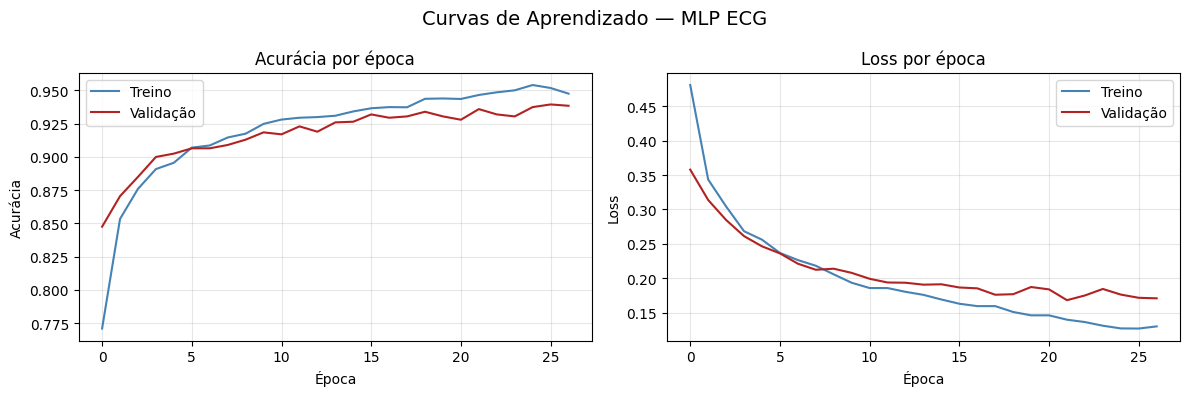

Gráfico salvo em: /content/curvas_aprendizado.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Curva de acurácia
axes[0].plot(historico.history['accuracy'],     label='Treino',    color='steelblue')
axes[0].plot(historico.history['val_accuracy'], label='Validação', color='firebrick')
axes[0].set_title('Acurácia por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Curva de loss
axes[1].plot(historico.history['loss'],     label='Treino',    color='steelblue')
axes[1].plot(historico.history['val_loss'], label='Validação', color='firebrick')
axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Curvas de Aprendizado — MLP ECG', fontsize=14)
plt.tight_layout()

# Salva no caminho correto para o ambiente
caminho_curvas = os.path.join(CAMINHO_SAIDA, 'curvas_aprendizado.png')
plt.savefig(caminho_curvas, dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfico salvo em: {caminho_curvas}')

## 8. Avaliação no conjunto de teste

In [9]:
# Gera probabilidades e converte para rótulos binários com threshold 0.5
y_prob = modelo.predict(X_test_scaled).flatten()
y_pred = (y_prob >= 0.5).astype(int)

acuracia = accuracy_score(y_test, y_pred)
print(f'Acurácia no conjunto de teste: {acuracia:.2%}\n')

print('Relatório de classificação:')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anormal']))

print('Matriz de confusão:')
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Real: Normal', 'Real: Anormal'],
    columns=['Previsto: Normal', 'Previsto: Anormal']
)
print(cm_df)

# Interpretação clínica dos erros
fn = cm[1][0]  # anormal classificado como normal
fp = cm[0][1]  # normal classificado como anormal
print(f'\nInterpretação clínica:')
print(f'  Falsos negativos (arritmia não detectada) : {fn}')
print(f'  Falsos positivos (normal classificado como anormal): {fp}')
print(f'  Em triagem clínica, falsos negativos são mais críticos:')
print(f'  um paciente com arritmia não detectada representa risco real.')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Acurácia no conjunto de teste: 93.90%

Relatório de classificação:
              precision    recall  f1-score   support

      Normal       0.92      0.96      0.94      1000
     Anormal       0.96      0.92      0.94      1000

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000

Matriz de confusão:
               Previsto: Normal  Previsto: Anormal
Real: Normal                963                 37
Real: Anormal                85                915

Interpretação clínica:
  Falsos negativos (arritmia não detectada) : 85
  Falsos positivos (normal classificado como anormal): 37
  Em triagem clínica, falsos negativos são mais críticos:
  um paciente com arritmia não detectada representa risco real.


---

## Considerações finais

Este módulo demonstra que uma rede neural MLP simples consegue classificar  
batimentos cardíacos com alta acurácia a partir do sinal bruto de ECG.

### Conexão com as fases seguintes

- **Fase 3 (IoT):** sensores wearables podem capturar sinais de ECG em tempo real e enviar para um modelo como este via MQTT
- **Fase 4 (Visão Computacional):** as imagens de ECG da Fase 1 podem ser processadas com CNNs, complementando a abordagem de sinal deste módulo
- **Fase 6 (Séries Temporais):** os 187 pontos de cada batimento são uma série temporal que pode ser modelada com LSTM ou modelos de atenção

### Limitações

- O modelo foi treinado com dados do MIT-BIH (1998) e pode não generalizar para dispositivos modernos com diferentes frequências de amostragem
- A classificação binária simplifica um problema clínico complexo com múltiplos tipos de arritmia
- O dataset MIT-BIH não documenta o sexo dos pacientes — limitação de governança registrada intencionalmente, pois impede a análise de viés de gênero neste módulo

**Este notebook não produz diagnósticos médicos. Tem finalidade exclusivamente acadêmica.**